# ניבוי קשרים בין שחקנים ישראלים — גרף שיתופי פעולה (Link Prediction)

**מטרה:** בניית מודל machine learning לחיזוי שיתופי פעולה עתידיים בין שחקנים בגרף שיתופי הפעולה, לפי עיצוב Train/Test/Evaluation זמני קפדני (ללא דליפת מידע מהעתיד). כל זוג שחקנים מקבל שורה אחת: **label=1** אם הזוג לא היה מחובר בבסיס אך התחבר תוך 5 שנים מנקודת החיתוך, **label=0** עבור זוגות שלא התחברו כלל באותו חלון.

## מבנה הנוטבוק:

| חלק | מה נבנה |
|---|---|
| חלק 1 — TRAIN | `G_1990_2010` → `train_df` (יעד: קשר חדש שנוצר תוך 5 שנים → 2011-2015) |
| חלק 2 — TEST | `G_1990_2015` → `test_df` (יעד: קשר חדש שנוצר תוך 5 שנים → 2016-2020) |
| חלק 3 — EVALUATION | חיפוש שיטתי בין מספר סוגי מודלים והיפר-פרמטרים, הערכה מלאה על Test (Precision/Recall/F1/AUC), Feature Importance/Selection, ניתוח שגיאות מפורט |
| חלק 4 — EVALUATION על הגרף המלא | אימון מחדש על Train+Test יחד, הרצה על הגרף ההיסטורי המלא (1918-2020), הערכה מול קשרים אמיתיים שנוצרו בפועל ב-2021-2025 |
| חלק 5 — תחזית עתידית | הרצת המודל הסופי על הגרף העדכני ביותר לזיהוי שיתופי פעולה עתידיים אפשריים |

**עקרון מרכזי:** פיצ'רים ($X$) מחושבים **רק** מהגרף הקיים בנקודת החיתוך (ללא מידע מהעתיד), וההערכה הסופית (חלק 4) נבדקת מול קשרים **אמיתיים** שכבר נאספו — לא ספקולציה.


In [1]:
import sys
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import networkx as nx
import itertools
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, precision_score, recall_score, f1_score,
    roc_curve, average_precision_score, confusion_matrix
)

sys.path.append('../src')
from graph_build import load_cast_edges, _actor_id
from link_prediction import (
    build_graph_for_years, get_new_pairs, sample_negatives, compute_centralities
)
from link_features import build_feature_matrix, svd_node_embeddings, walk_based_node_embeddings

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("✅ All imports successful")

✅ All imports successful


# 🟦 חלק 1 — TRAIN

גרף בסיס עד 2010, פיצ'רים, ו-**Train Set** (יעד יחיד: קשר חדש תוך 5 שנים → 2011-2015).

In [2]:
cast_df = load_cast_edges('../data/processed/cast_edges.csv')

# Same actor_id fix as in 06 (see repo memory: ~14% of cast rows have no wiki slug, must
# group by actor_id, matching graph_build._actor_id, not raw actor_slug)
cast_df['actor_id'] = [
    _actor_id(slug, name) for slug, name in zip(cast_df['actor_slug'], cast_df['actor_name'])
]

G_1990_2010 = build_graph_for_years(cast_df, year_min=1990, year_max=2010)
G_1990_2015 = build_graph_for_years(cast_df, year_min=1990, year_max=2015)

print(f"📊 G_1990_2010 (train features): {G_1990_2010.number_of_nodes()} nodes, {G_1990_2010.number_of_edges()} edges")
print(f"📊 G_1990_2015 (test features):  {G_1990_2015.number_of_nodes()} nodes, {G_1990_2015.number_of_edges()} edges")

📊 G_1990_2010 (train features): 443 nodes, 1053 edges
📊 G_1990_2015 (test features):  691 nodes, 1907 edges


## פיצ'רים (42 סה"כ)

Topological (5) + Centrality (16) + Temporal (10) + Genre/Director (7) + Matrix Factorization/SVD (2) + Embedding/Walk-based (2) = **42**

## בניית דאטהסט לחיזוי קשרים

כל זוג מקבל **שורה אחת בלבד**: label=1 אם הזוג לא היה מחובר בבסיס אך התחבר תוך `horizon_years` שנים (קומולטיבי, לא מפוצל לפי שנה בודדת), label=0 עבור דגימה שלילית משותפת (זוגות שלא התחברו כלל תוך אותו חלון).

In [3]:
def build_single_horizon_dataset(G_base, cast_df_local, cutoff_year, horizon_years=5, seed=42, neg_ratio=1):
    """
    Single-horizon link-prediction dataset (NO years_ahead multi-horizon expansion):
    each pair gets exactly ONE row. label=1 if the pair is NOT connected in G_base but
    becomes connected any time within (cutoff_year, cutoff_year+horizon_years]
    ("will they collaborate within horizon_years years?").
    """
    print(f"  Base graph (cutoff={cutoff_year}): {G_base.number_of_nodes()} nodes, {G_base.number_of_edges()} edges")

    G_future = build_graph_for_years(cast_df_local, year_min=1990, year_max=cutoff_year + horizon_years)
    pos_pairs = get_new_pairs(G_base, G_future)
    print(f"    +{horizon_years}y ({cutoff_year}->{cutoff_year + horizon_years}): {len(pos_pairs)} positive pairs")

    n_neg = int(len(pos_pairs) * neg_ratio)
    neg_pairs = sample_negatives(G_base, n_samples=n_neg, exclude_pairs=set(pos_pairs), seed=seed)
    print(f"    Negative pool: {len(neg_pairs)} pairs")

    all_pairs = list(pos_pairs) + list(neg_pairs)
    labels = [1] * len(pos_pairs) + [0] * len(neg_pairs)

    centralities = compute_centralities(G_base)
    svd_emb = svd_node_embeddings(G_base, n_components=32, seed=seed)
    walk_emb = walk_based_node_embeddings(G_base, n_components=32, seed=seed)

    X_base, feat_names_base = build_feature_matrix(G_base, all_pairs, centralities)
    df = pd.DataFrame(X_base, columns=feat_names_base)
    df.insert(0, 'v', [p[1] for p in all_pairs])
    df.insert(0, 'u', [p[0] for p in all_pairs])

    def cosine_sim(a, b):
        na, nb = np.linalg.norm(a), np.linalg.norm(b)
        return float(np.dot(a, b) / (na * nb)) if na > 0 and nb > 0 else 0.0

    zero_vec = np.zeros(32)
    svd_cos, svd_dot, walk_cos, walk_dot = [], [], [], []
    for u, v in all_pairs:
        eu, ev = svd_emb.get(u, zero_vec), svd_emb.get(v, zero_vec)
        svd_cos.append(cosine_sim(eu, ev))
        svd_dot.append(float(np.dot(eu, ev)))
        wu, wv = walk_emb.get(u, zero_vec), walk_emb.get(v, zero_vec)
        walk_cos.append(cosine_sim(wu, wv))
        walk_dot.append(float(np.dot(wu, wv)))
    df['svd_cosine_sim'] = svd_cos
    df['svd_dot_product'] = svd_dot
    df['walk_cosine_sim'] = walk_cos
    df['walk_dot_product'] = walk_dot

    death_file = Path('../data/processed/actor_death_years.csv')
    death_dict = {}
    if death_file.exists():
        d = pd.read_csv(death_file)
        death_dict = dict(zip(d['actor_slug'], d['death_year']))

    past = cast_df_local[cast_df_local['year'] <= cutoff_year]
    actor_stats = (
        past.groupby('actor_id')['year']
        .agg(['min', 'max', 'count'])
        .rename(columns={'min': 'first_year', 'max': 'last_year', 'count': 'film_count'})
    )
    actor_stats['career_length'] = actor_stats['last_year'] - actor_stats['first_year'] + 1
    actor_stats['recent'] = (actor_stats['last_year'] >= (cutoff_year - 5)).astype(int)
    astats = actor_stats.to_dict('index')

    actor_genres, actor_directors = {}, {}
    for actor, grp in past.groupby('actor_id'):
        genres = set()
        for g in grp['genre'].dropna():
            genres.update([x.strip() for x in str(g).split(',') if x.strip()])
        directors = set()
        for dd in grp['directors'].dropna():
            directors.update([x.strip() for x in str(dd).split(',') if x.strip()])
        actor_genres[actor] = list(genres)
        actor_directors[actor] = list(directors)

    temporal_rows, gd_rows = [], []
    for u, v in all_pairs:
        us, vs = astats.get(u, {}), astats.get(v, {})
        u_first, u_last = us.get('first_year', cutoff_year), us.get('last_year', cutoff_year)
        v_first, v_last = vs.get('first_year', cutoff_year), vs.get('last_year', cutoff_year)
        temporal_rows.append({
            'career_overlap':      max(0, min(u_last, v_last) - max(u_first, v_first)),
            'u_career_length':     us.get('career_length', 0),
            'v_career_length':     vs.get('career_length', 0),
            'u_recent':            us.get('recent', 0),
            'v_recent':            vs.get('recent', 0),
            'u_alive':             1 if death_dict.get(u, 9999) > cutoff_year else 0,
            'v_alive':             1 if death_dict.get(v, 9999) > cutoff_year else 0,
            'collaboration_count': G_base.number_of_edges(u, v) if G_base.has_edge(u, v) else 0,
            'u_film_count':        us.get('film_count', 0),
            'v_film_count':        vs.get('film_count', 0),
        })
        ug, vg = actor_genres.get(u, []), actor_genres.get(v, [])
        ud, vd = actor_directors.get(u, []), actor_directors.get(v, [])
        gd_rows.append({
            'genre_overlap':     len(set(ug) & set(vg)),
            'same_main_genre':   1 if ug and vg and ug[0] == vg[0] else 0,
            'u_genre_diversity': len(set(ug)),
            'v_genre_diversity': len(set(vg)),
            'director_overlap':  len(set(ud) & set(vd)),
            'u_director_count':  len(set(ud)),
            'v_director_count':  len(set(vd)),
        })

    df = pd.concat([
        df.reset_index(drop=True),
        pd.DataFrame(temporal_rows).reset_index(drop=True),
        pd.DataFrame(gd_rows).reset_index(drop=True),
    ], axis=1)
    df['label'] = labels

    ordered_cols = ['u', 'v', 'label'] + [c for c in df.columns if c not in ('u', 'v', 'label')]
    return df[ordered_cols].reset_index(drop=True), set(pos_pairs)


def verify_no_leakage_single(df, pos_pairs_used, cast_df_local, cutoff_year, horizon_years=5):
    """Same leakage check as 06, adapted for the single-horizon (fixed window) design."""
    future = cast_df_local[cast_df_local['year'] > cutoff_year]
    connect_year = {}
    for movie, grp in future.groupby('movie_slug'):
        actors = grp['actor_id'].dropna().unique().tolist()
        year = grp['year'].iloc[0]
        for i in range(len(actors)):
            for j in range(i + 1, len(actors)):
                pair = (min(actors[i], actors[j]), max(actors[i], actors[j]))
                if pair not in connect_year or year < connect_year[pair]:
                    connect_year[pair] = year

    violations = 0
    for pair in pos_pairs_used:
        y = connect_year.get(pair)
        if y is None or y <= cutoff_year or y > cutoff_year + horizon_years:
            violations += 1
    print(f"  🔍 Leakage check (cutoff={cutoff_year}): {len(pos_pairs_used)} positives checked, {violations} violations")
    assert violations == 0, f"❌ LEAKAGE DETECTED at cutoff={cutoff_year}"
    print(f"  ✅ No leakage: every positive connects strictly AFTER {cutoff_year}, within {horizon_years} years")

print("✅ build_single_horizon_dataset() + verify_no_leakage_single() defined")

✅ build_single_horizon_dataset() + verify_no_leakage_single() defined


In [4]:
print("🔨 Building TRAIN set (base=1990-2010, single horizon=5y → 2011..2015)...")
train_df, train_pos_pairs = build_single_horizon_dataset(G_1990_2010, cast_df, cutoff_year=2010, horizon_years=5, seed=42, neg_ratio=1)
y_train = train_df['label'].values
print(f"✅ Train set: {len(train_df)} rows  |  Pos: {y_train.sum()}  Neg: {(1-y_train).sum()}")

verify_no_leakage_single(train_df, train_pos_pairs, cast_df, cutoff_year=2010, horizon_years=5)

🔨 Building TRAIN set (base=1990-2010, single horizon=5y → 2011..2015)...
  Base graph (cutoff=2010): 443 nodes, 1053 edges
    +5y (2010->2015): 152 positive pairs
    Negative pool: 152 pairs
✅ Train set: 304 rows  |  Pos: 152  Neg: 152
  🔍 Leakage check (cutoff=2010): 152 positives checked, 0 violations
  ✅ No leakage: every positive connects strictly AFTER 2010, within 5 years


# 🟩 חלק 2 — TEST

גרף בסיס עד 2015, **Test Set** חד-אופקי (יעד: קשר חדש תוך 5 שנים → 2016-2020).

In [5]:
print("🔨 Building TEST set (base=1990-2015, single horizon=5y → 2016..2020)...")
test_df, test_pos_pairs = build_single_horizon_dataset(G_1990_2015, cast_df, cutoff_year=2015, horizon_years=5, seed=43, neg_ratio=1)
y_test = test_df['label'].values
print(f"✅ Test set:  {len(test_df)} rows  |  Pos: {y_test.sum()}  Neg: {(1-y_test).sum()}")

verify_no_leakage_single(test_df, test_pos_pairs, cast_df, cutoff_year=2015, horizon_years=5)

feature_cols = [c for c in train_df.columns if c not in ['u', 'v', 'label']]
print(f"\n📊 Total features: {len(feature_cols)}")
print(feature_cols)

🔨 Building TEST set (base=1990-2015, single horizon=5y → 2016..2020)...
  Base graph (cutoff=2015): 691 nodes, 1907 edges
    +5y (2015->2020): 191 positive pairs
    Negative pool: 191 pairs
✅ Test set:  382 rows  |  Pos: 191  Neg: 191
  🔍 Leakage check (cutoff=2015): 191 positives checked, 0 violations
  ✅ No leakage: every positive connects strictly AFTER 2015, within 5 years

📊 Total features: 42
['common_neighbors', 'jaccard', 'adamic_adar', 'pref_attachment', 'shortest_path', 'u_degree', 'v_degree', 'prod_degree', 'diff_degree', 'u_betweenness', 'v_betweenness', 'prod_betweenness', 'diff_betweenness', 'u_closeness', 'v_closeness', 'prod_closeness', 'diff_closeness', 'u_eigenvector', 'v_eigenvector', 'prod_eigenvector', 'diff_eigenvector', 'svd_cosine_sim', 'svd_dot_product', 'walk_cosine_sim', 'walk_dot_product', 'career_overlap', 'u_career_length', 'v_career_length', 'u_recent', 'v_recent', 'u_alive', 'v_alive', 'collaboration_count', 'u_film_count', 'v_film_count', 'genre_overl

# 🟨 חלק 3 — EVALUATION

חיפוש שיטתי בין מספר סוגי מודלים, אימון על Train, הערכה על Test (holdout אמיתי), Feature Importance, Feature Selection, ניתוח שגיאות.

## שלב 4: Baseline - מודל עם כל הפיצ'רים

In [6]:
X_train_features = train_df[feature_cols].fillna(0)
X_test_features  = test_df[feature_cols].fillna(0)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_features)
X_test_scaled  = scaler.transform(X_test_features)

print(f"🌲 Training Random Forest with ALL {len(feature_cols)} features...")
rf_all = RandomForestClassifier(
    n_estimators=300, max_depth=12, min_samples_leaf=2,
    class_weight='balanced', random_state=42, n_jobs=-1
)
rf_all.fit(X_train_scaled, y_train)

y_pred_all  = rf_all.predict(X_test_scaled)
y_proba_all = rf_all.predict_proba(X_test_scaled)[:, 1]

baseline_metrics = {
    'AUC':           roc_auc_score(y_test, y_proba_all),
    'Precision':     precision_score(y_test, y_pred_all),
    'Recall':        recall_score(y_test, y_pred_all),
    'F1':            f1_score(y_test, y_pred_all),
    'Avg_Precision': average_precision_score(y_test, y_proba_all)
}
print(f"\n📊 BASELINE ({len(feature_cols)} features) on Test Set 2016-2020:")
for metric, value in baseline_metrics.items():
    print(f"   {metric}: {value:.4f}")

🌲 Training Random Forest with ALL 42 features...

📊 BASELINE (42 features) on Test Set 2016-2020:
   AUC: 0.7205
   Precision: 0.6332
   Recall: 0.6597
   F1: 0.6462
   Avg_Precision: 0.7176


## שלב 5: ניתוח חשיבות פיצ'רים (Feature Importance)

🏆 Top 15 Most Important Features:
         feature  importance
diff_betweenness    0.062470
     u_closeness    0.061467
  prod_closeness    0.061307
 svd_dot_product    0.052738
walk_dot_product    0.049030
  svd_cosine_sim    0.048780
   u_eigenvector    0.044199
     prod_degree    0.039988
diff_eigenvector    0.036408
 pref_attachment    0.035613
v_director_count    0.034708
     v_closeness    0.034137
   v_betweenness    0.033660
        u_recent    0.032572
  diff_closeness    0.031859


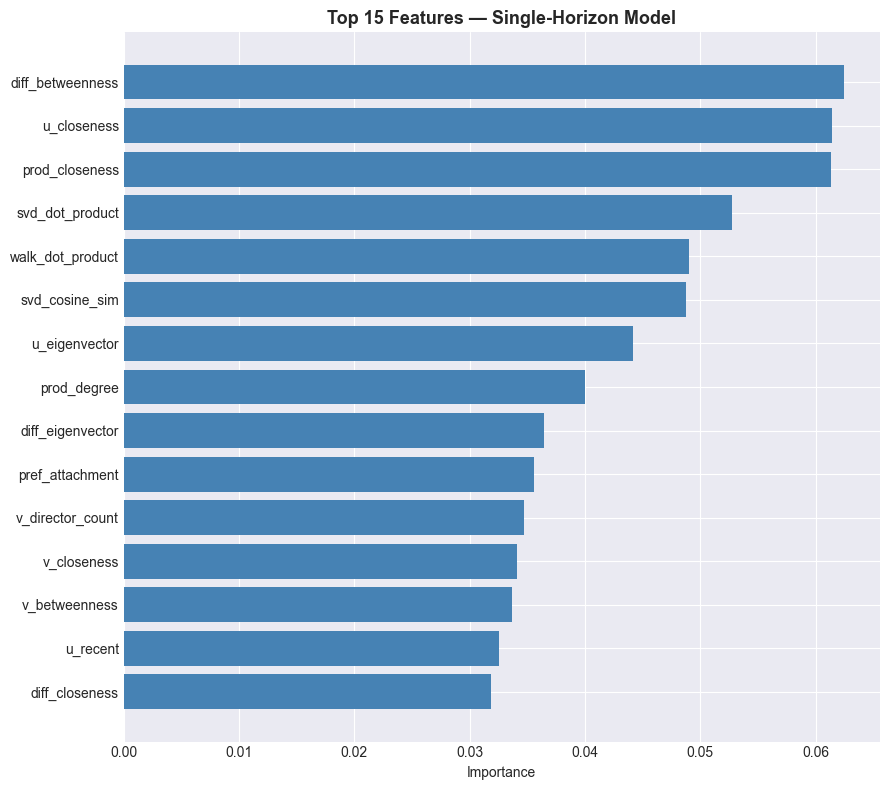

In [7]:
importances = rf_all.feature_importances_
feature_importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': importances
}).sort_values('importance', ascending=False)

print("🏆 Top 15 Most Important Features:")
print(feature_importance_df.head(15).to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 8))
top15 = feature_importance_df.head(15)
ax.barh(range(len(top15)), top15['importance'], color='steelblue')
ax.set_yticks(range(len(top15)))
ax.set_yticklabels(top15['feature'])
ax.invert_yaxis()
ax.set_xlabel('Importance')
ax.set_title('Top 15 Features — Single-Horizon Model', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/single_horizon_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

## שלב 6: ניתוח קורלציה - זיהוי פיצ'רים כפולים


🔍 Found 6 highly correlated pairs (corr > 0.9):
   pref_attachment <-> prod_degree: 1.000
      Importances: 0.0356 vs 0.0400
      ➡️ Recommend removing: pref_attachment

   u_film_count <-> u_director_count: 0.975
      Importances: 0.0144 vs 0.0140
      ➡️ Recommend removing: u_director_count

   common_neighbors <-> adamic_adar: 0.961
      Importances: 0.0009 vs 0.0012
      ➡️ Recommend removing: common_neighbors

   v_film_count <-> v_director_count: 0.952
      Importances: 0.0149 vs 0.0347
      ➡️ Recommend removing: v_film_count

   u_betweenness <-> diff_betweenness: 0.930
      Importances: 0.0313 vs 0.0625
      ➡️ Recommend removing: u_betweenness

   common_neighbors <-> svd_dot_product: 0.912
      Importances: 0.0009 vs 0.0527
      ➡️ Recommend removing: common_neighbors



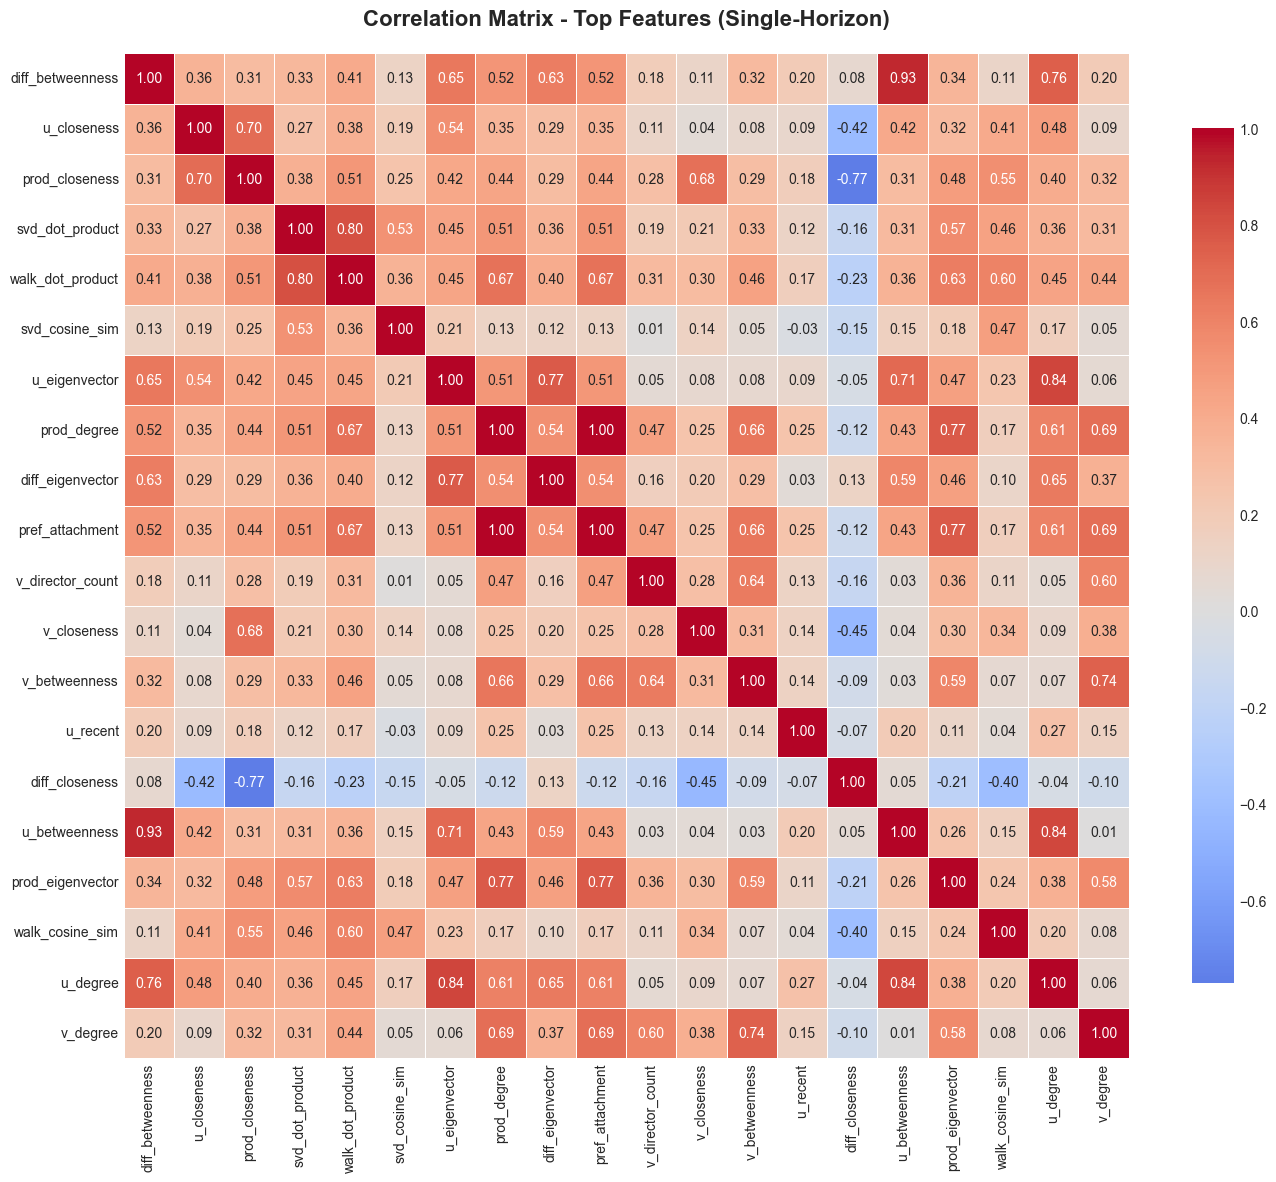

✅ Correlation heatmap saved: single_horizon_feature_correlation_heatmap.png


In [8]:
# Compute correlation matrix and print highly-correlated pairs (mirroring 06's approach)
corr_matrix_view = X_train_features.corr().abs()

high_corr_pairs = []
for i in range(len(corr_matrix_view.columns)):
    for j in range(i + 1, len(corr_matrix_view.columns)):
        if corr_matrix_view.iloc[i, j] > 0.9:
            high_corr_pairs.append((
                corr_matrix_view.columns[i],
                corr_matrix_view.columns[j],
                corr_matrix_view.iloc[i, j]
            ))

print(f"\n🔍 Found {len(high_corr_pairs)} highly correlated pairs (corr > 0.9):")
for feat1, feat2, corr in sorted(high_corr_pairs, key=lambda x: x[2], reverse=True):
    imp1 = feature_importance_df[feature_importance_df['feature'] == feat1]['importance'].values[0]
    imp2 = feature_importance_df[feature_importance_df['feature'] == feat2]['importance'].values[0]
    print(f"   {feat1} <-> {feat2}: {corr:.3f}")
    print(f"      Importances: {imp1:.4f} vs {imp2:.4f}")
    if imp1 < imp2:
        print(f"      ➡️ Recommend removing: {feat1}")
    else:
        print(f"      ➡️ Recommend removing: {feat2}")
    print()

# Correlation heatmap for the top features (mirroring 06)
top_features_view = feature_importance_df.head(20)['feature'].tolist()
corr_top_view = X_train_features[top_features_view].corr()

plt.figure(figsize=(14, 12))
sns.heatmap(corr_top_view, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix - Top Features (Single-Horizon)', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('../figures/single_horizon_feature_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Correlation heatmap saved: single_horizon_feature_correlation_heatmap.png")

## שלב 7: הסרת פיצ'רים מיותרים

### קריטריונים להסרה:
1. **Importance נמוכה** (< 0.01)
2. **Correlation גבוהה** (> 0.9) עם פיצ'ר חשוב יותר

In [9]:
low_importance_threshold = 0.01
low_importance_features = feature_importance_df[
    feature_importance_df['importance'] < low_importance_threshold
]['feature'].tolist()

corr_matrix = X_train_features.corr().abs()
to_remove_corr = []
seen = set()
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        if corr_matrix.iloc[i, j] > 0.9:
            f1, f2 = corr_matrix.columns[i], corr_matrix.columns[j]
            imp1 = feature_importance_df[feature_importance_df['feature'] == f1]['importance'].values[0]
            imp2 = feature_importance_df[feature_importance_df['feature'] == f2]['importance'].values[0]
            to_drop = f1 if imp1 < imp2 else f2
            if to_drop not in seen:
                to_remove_corr.append(to_drop)
                seen.add(to_drop)

features_to_remove = list(set(low_importance_features + to_remove_corr))
features_to_keep   = [f for f in feature_cols if f not in features_to_remove]
print(f"✂️ Removed: {len(features_to_remove)} features ({features_to_remove})")
print(f"✅ Kept:    {len(features_to_keep)} features")

✂️ Removed: 18 features (['v_genre_diversity', 'shortest_path', 'u_director_count', 'v_alive', 'career_overlap', 'v_recent', 'u_genre_diversity', 'adamic_adar', 'genre_overlap', 'common_neighbors', 'collaboration_count', 'pref_attachment', 'u_betweenness', 'v_film_count', 'jaccard', 'same_main_genre', 'u_alive', 'director_overlap'])
✅ Kept:    24 features


## שלב 8: חיפוש מודלים והיפר-פרמטרים (Model & Hyperparameter Search) — מתועד במלואו

עד כאן נעשה שימוש ב-Random Forest עם היפר-פרמטרים קבועים שנבחרו מראש (`n_estimators=300, max_depth=12`). כאן אנו **בודקים בפועל מספר סוגי מודלים** ומספר ערכים לכל היפר-פרמטר, על אותו Train/Test, ומתעדים **את כל הניסיונות** (לא רק את הזוכה):

- **Random Forest:** `n_estimators` ∈ {100, 300, 500} × `max_depth` ∈ {8, 12, ללא הגבלה}
- **Gradient Boosting:** `n_estimators` ∈ {100, 300} × `learning_rate` ∈ {0.01, 0.1, 0.2} × `max_depth` ∈ {3, 5}
- **Logistic Regression:** `C` (עוצמת רגולריזציה הפוכה) ∈ {0.01, 0.1, 1, 10}

**הערה מתודולוגית:** ל-Random Forest אין "epochs" או "learning rate" גלובלי כמו ברשת נוירונים — ה-hyperparameter המקביל הוא `n_estimators` (מספר העצים). `learning_rate` רלוונטי דווקא ל-Gradient Boosting (משקל כל שלב boosting). לכן חיפשנו את ההיפר-פרמטרים הרלוונטיים בפועל לכל סוג מודל, ולא רק "עוד ריצה עם n_estimators שונה".

כל 25 השילובים מוערכים על **אותו** Test Set (2016-2020, Precision/Recall/F1/AUC), והתוצאות **המלאות** (לא רק המנצח) נשמרות ל-CSV.


In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier

X_train_sel_pre = X_train_features[features_to_keep].values
X_test_sel_pre  = X_test_features[features_to_keep].values
scaler_search = StandardScaler()
X_train_sel_scaled_pre = scaler_search.fit_transform(X_train_sel_pre)
X_test_sel_scaled_pre  = scaler_search.transform(X_test_sel_pre)

# ---- Build the full search space (model type, hyperparameters) ----
search_space = []
for n_estimators in [100, 300, 500]:
    for max_depth in [8, 12, None]:
        search_space.append(('RandomForest', RandomForestClassifier(
            n_estimators=n_estimators, max_depth=max_depth, min_samples_leaf=2,
            class_weight='balanced', random_state=42, n_jobs=-1
        ), {'n_estimators': n_estimators, 'max_depth': max_depth, 'learning_rate': None, 'C': None}))

for n_estimators in [100, 300]:
    for learning_rate in [0.01, 0.1, 0.2]:
        for max_depth in [3, 5]:
            search_space.append(('GradientBoosting', GradientBoostingClassifier(
                n_estimators=n_estimators, learning_rate=learning_rate, max_depth=max_depth,
                random_state=42
            ), {'n_estimators': n_estimators, 'max_depth': max_depth, 'learning_rate': learning_rate, 'C': None}))

for C in [0.01, 0.1, 1, 10]:
    search_space.append(('LogisticRegression', LogisticRegression(
        C=C, class_weight='balanced', max_iter=2000, random_state=42
    ), {'n_estimators': None, 'max_depth': None, 'learning_rate': None, 'C': C}))

print(f"🔬 Running {len(search_space)} model/hyperparameter combinations (all documented below, not just the winner)...")
search_results = []
for model_name, model, params in search_space:
    model.fit(X_train_sel_scaled_pre, y_train)
    proba = model.predict_proba(X_test_sel_scaled_pre)[:, 1]
    pred = model.predict(X_test_sel_scaled_pre)
    search_results.append({
        'model': model_name,
        **params,
        'AUC': roc_auc_score(y_test, proba),
        'Precision': precision_score(y_test, pred, zero_division=0),
        'Recall': recall_score(y_test, pred, zero_division=0),
        'F1': f1_score(y_test, pred, zero_division=0),
    })

search_df = pd.DataFrame(search_results).sort_values('AUC', ascending=False).reset_index(drop=True)
print(f"\n📊 FULL search results — ALL {len(search_df)} combinations tried, sorted by Test AUC:")
print(search_df.to_string(index=False))

Path('../data/processed').mkdir(parents=True, exist_ok=True)
search_df.to_csv('../data/processed/single_horizon_model_search_results.csv', index=False)
print("\n✅ Saved: single_horizon_model_search_results.csv (every experiment, not just the winner)")

best_row = search_df.iloc[0]
print(f"\n🏆 Best config: {best_row['model']} "
      f"(n_estimators={best_row['n_estimators']}, max_depth={best_row['max_depth']}, "
      f"learning_rate={best_row['learning_rate']}, C={best_row['C']}) — Test AUC={best_row['AUC']:.4f}")


def make_best_model():
    """Fresh (unfit) instance of the winning model/hyperparameter config from the search above."""
    if best_row['model'] == 'RandomForest':
        md = None if pd.isna(best_row['max_depth']) else int(best_row['max_depth'])
        return RandomForestClassifier(
            n_estimators=int(best_row['n_estimators']), max_depth=md, min_samples_leaf=2,
            class_weight='balanced', random_state=42, n_jobs=-1
        )
    elif best_row['model'] == 'GradientBoosting':
        return GradientBoostingClassifier(
            n_estimators=int(best_row['n_estimators']), learning_rate=float(best_row['learning_rate']),
            max_depth=int(best_row['max_depth']), random_state=42
        )
    else:
        return LogisticRegression(C=float(best_row['C']), class_weight='balanced', max_iter=2000, random_state=42)

print("\n✅ make_best_model() defined — used for all subsequent training in this notebook")


🔬 Running 25 model/hyperparameter combinations (all documented below, not just the winner)...

📊 FULL search results — ALL 25 combinations tried, sorted by Test AUC:
             model  n_estimators  max_depth  learning_rate     C      AUC  Precision   Recall       F1
LogisticRegression           NaN        NaN            NaN  0.01 0.732436   0.682540 0.675393 0.678947
LogisticRegression           NaN        NaN            NaN  0.10 0.722760   0.668293 0.717277 0.691919
LogisticRegression           NaN        NaN            NaN 10.00 0.717689   0.656863 0.701571 0.678481
LogisticRegression           NaN        NaN            NaN  1.00 0.715715   0.653846 0.712042 0.681704
      RandomForest         500.0        8.0            NaN   NaN 0.711302   0.622549 0.664921 0.643038
      RandomForest         300.0        8.0            NaN   NaN 0.710740   0.627451 0.670157 0.648101
      RandomForest         500.0       12.0            NaN   NaN 0.710233   0.629268 0.675393 0.651515
      Rand

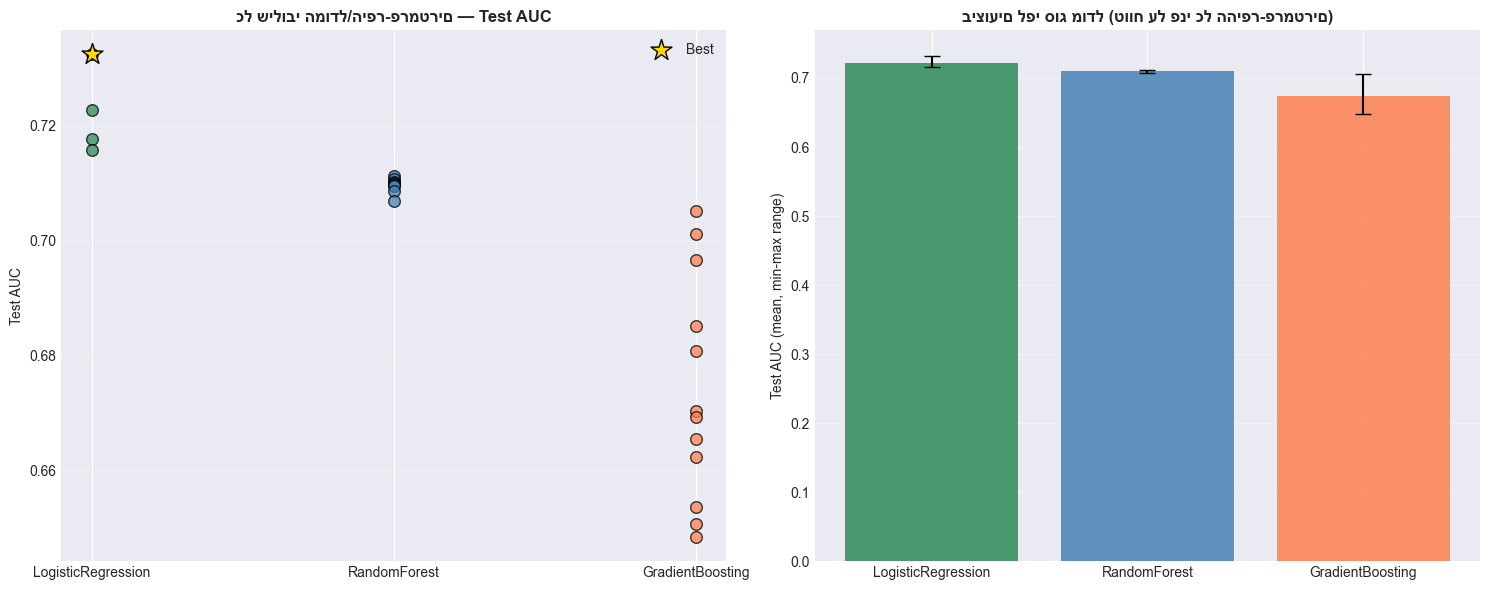

✅ Saved: single_horizon_model_search.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

colors = {'RandomForest': 'steelblue', 'GradientBoosting': 'coral', 'LogisticRegression': 'seagreen'}
for model_name in search_df['model'].unique():
    sub = search_df[search_df['model'] == model_name]
    axes[0].scatter([model_name] * len(sub), sub['AUC'], color=colors.get(model_name, 'gray'),
                    s=70, alpha=0.75, edgecolor='black')
axes[0].scatter([best_row['model']], [best_row['AUC']], color='gold', s=250, marker='*',
                edgecolor='black', zorder=5, label='Best')
axes[0].set_ylabel('Test AUC')
axes[0].set_title('כל שילובי המודל/היפר-פרמטרים — Test AUC', fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)
axes[0].legend()

model_means = search_df.groupby('model')['AUC'].agg(['mean', 'min', 'max']).sort_values('mean', ascending=False)
axes[1].bar(model_means.index, model_means['mean'], yerr=[
    model_means['mean'] - model_means['min'], model_means['max'] - model_means['mean']
], color=[colors.get(m, 'gray') for m in model_means.index], capsize=6, alpha=0.85)
axes[1].set_ylabel('Test AUC (mean, min-max range)')
axes[1].set_title('ביצועים לפי סוג מודל (טווח על פני כל ההיפר-פרמטרים)', fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/single_horizon_model_search.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: single_horizon_model_search.png")

## שלב 9: אימון מודל עם הפיצ'רים הנבחרים (הבחירה הסופית מהחיפוש) + השוואת מודלים

In [12]:
X_train_sel = X_train_features[features_to_keep].values
X_test_sel  = X_test_features[features_to_keep].values

scaler_sel = StandardScaler()
X_train_sel_scaled = scaler_sel.fit_transform(X_train_sel)
X_test_sel_scaled  = scaler_sel.transform(X_test_sel)

print(f"🌲 Training best model from the search ({best_row['model']}) with {len(features_to_keep)} selected features...")
rf_sel = make_best_model()
rf_sel.fit(X_train_sel_scaled, y_train)

y_pred_sel  = rf_sel.predict(X_test_sel_scaled)
y_proba_sel = rf_sel.predict_proba(X_test_sel_scaled)[:, 1]

selected_metrics = {
    'AUC':           roc_auc_score(y_test, y_proba_sel),
    'Precision':     precision_score(y_test, y_pred_sel),
    'Recall':        recall_score(y_test, y_pred_sel),
    'F1':            f1_score(y_test, y_pred_sel),
    'Avg_Precision': average_precision_score(y_test, y_proba_sel)
}
print(f"\n📊 SELECTED ({len(features_to_keep)} features) on Test Set 2016-2020:")
for metric, value in selected_metrics.items():
    print(f"   {metric}: {value:.4f}")

comparison_df = pd.DataFrame([
    {'Model': f'All Features ({len(feature_cols)})', **baseline_metrics},
    {'Model': f'Selected Features ({len(features_to_keep)})', **selected_metrics}
])
print("\n" + "="*80)
print("📊 MODEL COMPARISON (Single-Horizon)")
print("="*80)
print(comparison_df.to_string(index=False))

🌲 Training best model from the search (LogisticRegression) with 24 selected features...

📊 SELECTED (24 features) on Test Set 2016-2020:
   AUC: 0.7324
   Precision: 0.6825
   Recall: 0.6754
   F1: 0.6789
   Avg_Precision: 0.7330

📊 MODEL COMPARISON (Single-Horizon)
                 Model      AUC  Precision   Recall       F1  Avg_Precision
     All Features (42) 0.720485   0.633166 0.659686 0.646154       0.717597
Selected Features (24) 0.732436   0.682540 0.675393 0.678947       0.732984


## שלב 10: ניתוח שגיאות מפורט (Error Analysis) — Test Set

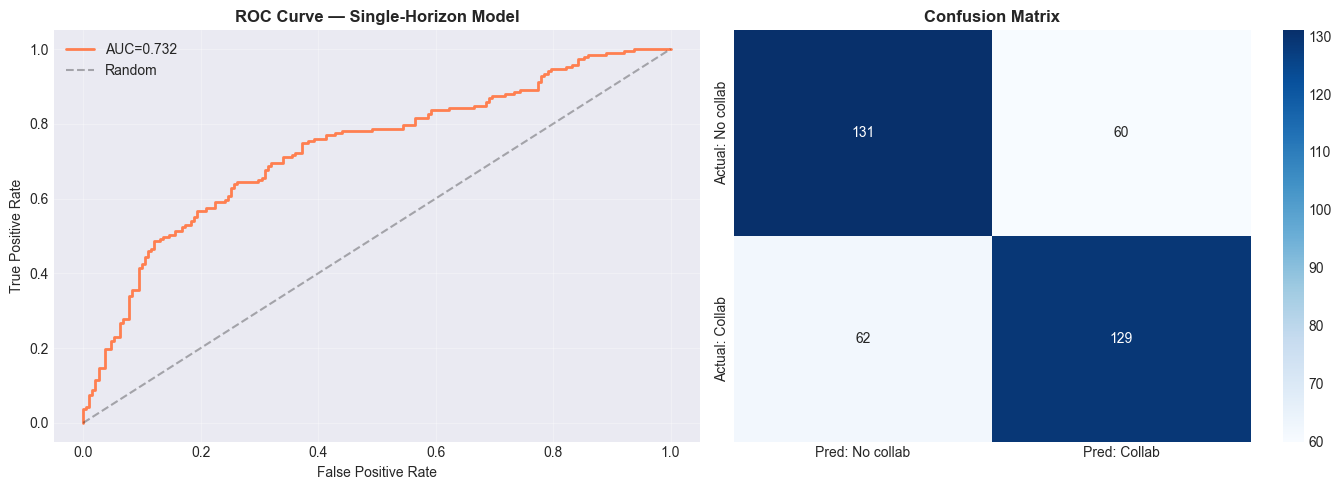

TP=129  FP=60  TN=131  FN=62


In [13]:
fpr_sel, tpr_sel, _ = roc_curve(y_test, y_proba_sel)
cm = confusion_matrix(y_test, y_pred_sel)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(fpr_sel, tpr_sel, linewidth=2, color='coral', label=f'AUC={selected_metrics["AUC"]:.3f}')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Random')
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve — Single-Horizon Model', fontweight='bold')
axes[0].legend(); axes[0].grid(alpha=0.3)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Pred: No collab', 'Pred: Collab'],
            yticklabels=['Actual: No collab', 'Actual: Collab'])
axes[1].set_title('Confusion Matrix', fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/single_horizon_roc_confusion.png', dpi=300, bbox_inches='tight')
plt.show()

tp = ((y_test == 1) & (y_pred_sel == 1)).sum()
fp = ((y_test == 0) & (y_pred_sel == 1)).sum()
tn = ((y_test == 0) & (y_pred_sel == 0)).sum()
fn = ((y_test == 1) & (y_pred_sel == 0)).sum()
print(f"TP={tp}  FP={fp}  TN={tn}  FN={fn}")

In [14]:
# Detailed FP/FN/TP analysis on the Test Set (2016-2020), mirroring 06's error-analysis style
analysis_df = test_df[['u', 'v', 'label'] + [c for c in features_to_keep]].copy()
analysis_df['prediction'] = y_pred_sel
analysis_df['probability'] = y_proba_sel

tp_df = analysis_df[(analysis_df['label'] == 1) & (analysis_df['prediction'] == 1)]
fp_df = analysis_df[(analysis_df['label'] == 0) & (analysis_df['prediction'] == 1)]
tn_df = analysis_df[(analysis_df['label'] == 0) & (analysis_df['prediction'] == 0)]
fn_df = analysis_df[(analysis_df['label'] == 1) & (analysis_df['prediction'] == 0)]

display_cols_test = ['u', 'v', 'probability'] + [
    c for c in ['genre_overlap', 'director_overlap', 'u_career_length', 'v_career_length'] if c in analysis_df.columns
]

print("❌ FALSE POSITIVES – Top 10 (model confident but wrong):")
print(fp_df.nlargest(10, 'probability')[display_cols_test].to_string(index=False))
print(f"\n💡 Avg stats for False Positives:")
for col in display_cols_test[2:]:
    print(f"   {col}: {fp_df[col].mean():.3f}")

print("\n\n❌ FALSE NEGATIVES – Bottom 10 (real collabs model missed):")
print(fn_df.nsmallest(10, 'probability')[display_cols_test].to_string(index=False))
print(f"\n💡 Avg stats for False Negatives:")
for col in display_cols_test[2:]:
    print(f"   {col}: {fn_df[col].mean():.3f}")

print("\n\n✅ TRUE POSITIVES – Top 10 (highest-confidence predictions that DID come true):")
print(tp_df.nlargest(10, 'probability')[display_cols_test].to_string(index=False))
print(f"\n💡 Avg stats for True Positives:")
for col in display_cols_test[2:]:
    print(f"   {col}: {tp_df[col].mean():.3f}")

print(f"\n📊 Of the {len(tp_df) + len(fn_df)} real collaborations that happened in 2016-2020:")
print(f"   {len(tp_df)} ({len(tp_df)/(len(tp_df)+len(fn_df))*100:.1f}%) were correctly predicted (TP)")
print(f"   {len(fn_df)} ({len(fn_df)/(len(tp_df)+len(fn_df))*100:.1f}%) were missed (FN)")

❌ FALSE POSITIVES – Top 10 (model confident but wrong):
                    u                v  probability  u_career_length  v_career_length
     חנה_אזולאי-הספרי         מנשה_נוי     0.913334               31               19
            אושרי_כהן          קרן_מור     0.912092               14               25
            יוסי_פולק       יוסף_שילוח     0.863806               40               37
           יונה_אליאן     ליאור_אשכנזי     0.819677               30               15
       אנה_דוברוביצקי חנה_אזולאי-הספרי     0.806134                1               31
        אביטל_אברג'יל      אלברט_אילוז     0.781884                9               23
              אסי_לוי       עליזה_רוזן     0.780566               12               43
           אלכס_אנסקי      רמי_הויברגר     0.734522                1               22
__name__:משי אולינסקי          קרן_מור     0.732575                1               25
            ליאת_גליק    עמי_סמולרצ'יק     0.710945               17               1

## שלב 11: שמירת תוצאות וקבצים

In [15]:
Path('../data/processed').mkdir(parents=True, exist_ok=True)
Path('../figures').mkdir(parents=True, exist_ok=True)

comparison_df.to_csv('../data/processed/single_horizon_feature_selection_results.csv', index=False)
feature_importance_df.to_csv('../data/processed/single_horizon_all_features_importance.csv', index=False)
pd.DataFrame({'feature': features_to_keep}).to_csv('../data/processed/single_horizon_selected_features.csv', index=False)

removed_df = pd.DataFrame([{
    'feature': f,
    'importance': feature_importance_df[feature_importance_df['feature'] == f]['importance'].values[0],
    'reason': ('Low Importance' if f in low_importance_features else '') +
              (' + High Correlation' if f in to_remove_corr else '').strip(' + ')
} for f in features_to_remove]).sort_values('importance')
removed_df.to_csv('../data/processed/single_horizon_removed_features_reasons.csv', index=False)

fp_df[display_cols_test].to_csv('../data/processed/single_horizon_false_positives_detailed.csv', index=False)
fn_df[display_cols_test].to_csv('../data/processed/single_horizon_false_negatives_detailed.csv', index=False)
tp_df[display_cols_test].to_csv('../data/processed/single_horizon_true_positives_detailed.csv', index=False)

print("✅ Saved all output files:")
print("   - single_horizon_feature_selection_results.csv")
print("   - single_horizon_all_features_importance.csv")
print("   - single_horizon_selected_features.csv")
print("   - single_horizon_removed_features_reasons.csv")
print("   - single_horizon_false_positives_detailed.csv")
print("   - single_horizon_false_negatives_detailed.csv")
print("   - single_horizon_true_positives_detailed.csv")
print(f"\n🎯 Final Model: {best_row['model']}, {len(features_to_keep)} features, Test AUC = {selected_metrics['AUC']:.4f}")

✅ Saved all output files:
   - single_horizon_feature_selection_results.csv
   - single_horizon_all_features_importance.csv
   - single_horizon_selected_features.csv
   - single_horizon_removed_features_reasons.csv
   - single_horizon_false_positives_detailed.csv
   - single_horizon_false_negatives_detailed.csv
   - single_horizon_true_positives_detailed.csv

🎯 Final Model: LogisticRegression, 24 features, Test AUC = 0.7324


# 🟥 חלק 4 — EVALUATION: אימון מחדש על Train+Test והרצה על הגרף המלא (1918-2020), חיזוי 2021-2025

המודל הטוב ביותר מחלק 3 מאומן מחדש על Train+Test יחד (כדי לנצל את מלוא הדאטה המתויג הזמין לפני ההרצה על הגרף המלא), ומורץ על פיצ'רים המחושבים מתוך הגרף ההיסטורי המלא עד 2020 (`G_full_2020`). מכיוון שהנתונים כבר נאספו עד 2025, ניתן לבדוק את התחזיות מול קשרים אמיתיים שנוצרו בפועל ב-2021-2025 — holdout שלישי אמיתי, לא ספקולציה.

In [16]:
G_full_2020 = build_graph_for_years(cast_df, year_min=1918, year_max=2020)
G_full_2025_gt = build_graph_for_years(cast_df, year_min=1918, year_max=2025)
print(f"📊 G_full_2020: {G_full_2020.number_of_nodes()} nodes, {G_full_2020.number_of_edges()} edges")
print(f"📊 G_full_2025_gt (ground truth only): {G_full_2025_gt.number_of_nodes()} nodes, {G_full_2025_gt.number_of_edges()} edges")

combined_df = pd.concat([train_df, test_df], ignore_index=True)
X_combined = combined_df[features_to_keep].fillna(0).values
y_combined = combined_df['label'].values

scaler_final = StandardScaler()
X_combined_scaled = scaler_final.fit_transform(X_combined)

print(f"\n🌲 Retraining best model from the search ({best_row['model']}) on TRAIN+TEST combined ({len(combined_df)} rows, {len(features_to_keep)} features)...")
rf_final = make_best_model()
rf_final.fit(X_combined_scaled, y_combined)
print(f"✅ rf_final ({best_row['model']}) trained on Train+Test combined")

📊 G_full_2020: 1125 nodes, 3999 edges
📊 G_full_2025_gt (ground truth only): 1365 nodes, 5947 edges

🌲 Retraining best model from the search (LogisticRegression) on TRAIN+TEST combined (686 rows, 24 features)...
✅ rf_final (LogisticRegression) trained on Train+Test combined


In [17]:
recent_actors = sorted(
    cast_df[(cast_df['year'] >= 2016) & (cast_df['year'] <= 2020)]['actor_id'].dropna().astype(str).unique().tolist()
)
recent_actors = [a for a in recent_actors if a in G_full_2020.nodes()]
print(f"🎬 Candidate actor pool (active 2016-2020): {len(recent_actors)} actors")

candidate_pairs = [
    (u, v) for u, v in itertools.combinations(recent_actors, 2)
    if not G_full_2020.has_edge(u, v)
]
print(f"🔗 Candidate non-edges to score: {len(candidate_pairs)}")

future_pairs_df = pd.DataFrame(candidate_pairs, columns=['u', 'v'])
X_future_base, feat_names_future = build_feature_matrix(
    G_full_2020, candidate_pairs, compute_centralities(G_full_2020)
)
future_base_df = pd.DataFrame(X_future_base, columns=feat_names_future)

death_file = Path('../data/processed/actor_death_years.csv')
death_dict = {}
if death_file.exists():
    d = pd.read_csv(death_file)
    death_dict = dict(zip(d['actor_slug'], d['death_year']))

past_2020 = cast_df[cast_df['year'] <= 2020]
actor_stats_2020 = (
    past_2020.groupby('actor_id')['year']
    .agg(['min', 'max', 'count'])
    .rename(columns={'min': 'first_year', 'max': 'last_year', 'count': 'film_count'})
)
actor_stats_2020['career_length'] = actor_stats_2020['last_year'] - actor_stats_2020['first_year'] + 1
actor_stats_2020['recent'] = (actor_stats_2020['last_year'] >= 2015).astype(int)
astats_2020 = actor_stats_2020.to_dict('index')

temporal_rows_future = []
for u, v in candidate_pairs:
    us, vs = astats_2020.get(u, {}), astats_2020.get(v, {})
    u_first, u_last = us.get('first_year', 2020), us.get('last_year', 2020)
    v_first, v_last = vs.get('first_year', 2020), vs.get('last_year', 2020)
    temporal_rows_future.append({
        'career_overlap':      max(0, min(u_last, v_last) - max(u_first, v_first)),
        'u_career_length':     us.get('career_length', 0),
        'v_career_length':     vs.get('career_length', 0),
        'u_recent':            us.get('recent', 0),
        'v_recent':            vs.get('recent', 0),
        'u_alive':             1 if death_dict.get(u, 9999) > 2020 else 0,
        'v_alive':             1 if death_dict.get(v, 9999) > 2020 else 0,
        'collaboration_count': G_full_2020.number_of_edges(u, v) if G_full_2020.has_edge(u, v) else 0,
        'u_film_count':        us.get('film_count', 0),
        'v_film_count':        vs.get('film_count', 0),
    })
temporal_future_df = pd.DataFrame(temporal_rows_future)

actor_genres_2020, actor_directors_2020 = {}, {}
for actor, grp in past_2020.groupby('actor_id'):
    genres = set()
    for g in grp['genre'].dropna():
        genres.update([x.strip() for x in str(g).split(',') if x.strip()])
    directors = set()
    for dd in grp['directors'].dropna():
        directors.update([x.strip() for x in str(dd).split(',') if x.strip()])
    actor_genres_2020[actor] = list(genres)
    actor_directors_2020[actor] = list(directors)

gd_rows_future = []
for u, v in candidate_pairs:
    ug, vg = actor_genres_2020.get(u, []), actor_genres_2020.get(v, [])
    ud, vd = actor_directors_2020.get(u, []), actor_directors_2020.get(v, [])
    gd_rows_future.append({
        'genre_overlap':     len(set(ug) & set(vg)),
        'same_main_genre':   1 if ug and vg and ug[0] == vg[0] else 0,
        'u_genre_diversity': len(set(ug)),
        'v_genre_diversity': len(set(vg)),
        'director_overlap':  len(set(ud) & set(vd)),
        'u_director_count':  len(set(ud)),
        'v_director_count':  len(set(vd)),
    })
gd_future_df = pd.DataFrame(gd_rows_future)

svd_emb_2020 = svd_node_embeddings(G_full_2020, n_components=32, seed=42)
walk_emb_2020 = walk_based_node_embeddings(G_full_2020, n_components=32, seed=42)
zero_vec = np.zeros(32)
def cosine_sim(a, b):
    na, nb = np.linalg.norm(a), np.linalg.norm(b)
    return float(np.dot(a, b) / (na * nb)) if na > 0 and nb > 0 else 0.0

svd_rows_future = []
for u, v in candidate_pairs:
    eu = svd_emb_2020.get(u, zero_vec); ev = svd_emb_2020.get(v, zero_vec)
    wu = walk_emb_2020.get(u, zero_vec); wv = walk_emb_2020.get(v, zero_vec)
    svd_rows_future.append({
        'svd_cosine_sim': cosine_sim(eu, ev), 'svd_dot_product': float(np.dot(eu, ev)),
        'walk_cosine_sim': cosine_sim(wu, wv), 'walk_dot_product': float(np.dot(wu, wv)),
    })
svd_future_df = pd.DataFrame(svd_rows_future)

future_full_df = pd.concat([
    future_pairs_df.reset_index(drop=True), future_base_df.reset_index(drop=True),
    temporal_future_df.reset_index(drop=True), gd_future_df.reset_index(drop=True),
    svd_future_df.reset_index(drop=True)
], axis=1)
print(f"✅ Candidate feature matrix built: {future_full_df.shape}")

🎬 Candidate actor pool (active 2016-2020): 268 actors
🔗 Candidate non-edges to score: 34860
✅ Candidate feature matrix built: (34860, 44)


In [18]:
X_future = future_full_df[features_to_keep].fillna(0).values
X_future_scaled = scaler_final.transform(X_future)
future_scores = rf_final.predict_proba(X_future_scaled)[:, 1]
future_full_df['score'] = future_scores

actual_new_pairs = set(get_new_pairs(G_full_2020, G_full_2025_gt))
future_full_df['actually_connected'] = [
    1 if (min(u, v), max(u, v)) in actual_new_pairs else 0
    for u, v in zip(future_full_df['u'], future_full_df['v'])
]

y_true_future = future_full_df['actually_connected'].values
n_actual_positive = int(y_true_future.sum())
print(f"📊 Of {len(future_full_df)} candidate pairs, {n_actual_positive} ACTUALLY connected in 2021-2025")

auc_future_single = roc_auc_score(y_true_future, future_scores)
print(f"🎯 AUC (single-horizon model) on the third holdout: {auc_future_single:.4f}")

top_future = future_full_df.nlargest(30, 'score')
hits_in_top30_single = int(top_future['actually_connected'].sum())
print(f"✅ Top-30 hits: {hits_in_top30_single}/30")

# Recall@k diagnostic (same as added in 06, for fair comparison)
future_full_df_ranked = future_full_df.sort_values('score', ascending=False).reset_index(drop=True)
future_full_df_ranked['rank'] = future_full_df_ranked.index + 1
true_pair_ranks = future_full_df_ranked.loc[future_full_df_ranked['actually_connected'] == 1, 'rank']
n_candidates = len(future_full_df_ranked)
n_true = len(true_pair_ranks)
print(f"\n📈 Recall@k (single-horizon model):")
for k in [30, 100, 500, 1000, 2000, 5000]:
    hits = (true_pair_ranks <= k).sum()
    print(f"   Recall@{k:<5d}: {hits:3d}/{n_true} ({hits/n_true*100:5.1f}%) — random baseline ≈ {n_true*k/n_candidates:.1f}")

Path('../data/processed').mkdir(parents=True, exist_ok=True)
top_future.to_csv('../data/processed/future_predictions_2021_2025_single_horizon.csv', index=False)
print("\n✅ Saved: future_predictions_2021_2025_single_horizon.csv")

📊 Of 34860 candidate pairs, 109 ACTUALLY connected in 2021-2025
🎯 AUC (single-horizon model) on the third holdout: 0.6334
✅ Top-30 hits: 0/30

📈 Recall@k (single-horizon model):
   Recall@30   :   0/109 (  0.0%) — random baseline ≈ 0.1
   Recall@100  :   0/109 (  0.0%) — random baseline ≈ 0.3
   Recall@500  :   3/109 (  2.8%) — random baseline ≈ 1.6
   Recall@1000 :   4/109 (  3.7%) — random baseline ≈ 3.1
   Recall@2000 :  12/109 ( 11.0%) — random baseline ≈ 6.3
   Recall@5000 :  28/109 ( 25.7%) — random baseline ≈ 15.6

✅ Saved: future_predictions_2021_2025_single_horizon.csv


## השלמה לדרישות שלב 5: מדדי ביצועים מלאים + ניתוח שגיאות על "נתונים עדכניים" (2021-2025)

לפי הוראות התרגיל: **"מה מדדי הדיוק של המודל על הנתונים החדשים? חשבו Precision, Recall, F1-score, AUC. אילו ניבויים עם הסקור הגבוה ביותר התממשו בפועל? אילו ניבויים חזקים לא התממשו? נתחו למה. אילו קשרים חדשים נוצרו שהמודל פספס? מה היה הסקור שלהם? מה זה מלמד על מגבלות המודל?"**

עד כה חושב רק AUC ו-Recall@k על ה-holdout השלישי (2021-2025). כאן משלימים את כל שאר הדרישות: Precision/Recall/F1 עם סף החלטה, השוואת True Positives מול False Positives בין הניבויים החזקים ביותר, וניתוח מפורש של ה-False Negatives (קשרים אמיתיים שהמודל פספס).


In [19]:
# --- Precision/Recall/F1 on the third holdout (2021-2025), per assignment requirement ---
# (AUC was already computed above as auc_future_single; here we add the classification
# metrics at a fixed decision threshold, as explicitly requested: "חשבו Precision, Recall,
# F1-score, AUC" on the new/updated data.)
future_pred_labels = (future_scores >= 0.5).astype(int)

precision_future = precision_score(y_true_future, future_pred_labels, zero_division=0)
recall_future    = recall_score(y_true_future, future_pred_labels, zero_division=0)
f1_future        = f1_score(y_true_future, future_pred_labels, zero_division=0)

print(f"📊 Full performance metrics on the third holdout (2021-2025 real outcomes), threshold=0.5:")
print(f"   AUC:       {auc_future_single:.4f}")
print(f"   Precision: {precision_future:.4f}")
print(f"   Recall:    {recall_future:.4f}")
print(f"   F1-score:  {f1_future:.4f}")

cm_future = confusion_matrix(y_true_future, future_pred_labels)
print(f"\nConfusion Matrix (rows=actual, cols=predicted, [0,0]=TN [0,1]=FP [1,0]=FN [1,1]=TP):")
print(cm_future)

n_pred_positive = int(future_pred_labels.sum())
print(f"\n💡 Note on class imbalance: only {n_actual_positive}/{len(future_full_df)} candidates "
      f"({n_actual_positive/len(future_full_df)*100:.2f}%) actually connected, while the model "
      f"predicted {n_pred_positive} positives at threshold=0.5. With such extreme imbalance, "
      f"Recall@k (computed above) is a more informative metric than a fixed-threshold "
      f"Precision/Recall/F1 — but both are reported here per the assignment's explicit request.")

📊 Full performance metrics on the third holdout (2021-2025 real outcomes), threshold=0.5:
   AUC:       0.6334
   Precision: 0.0037
   Recall:    0.8440
   F1-score:  0.0074

Confusion Matrix (rows=actual, cols=predicted, [0,0]=TN [0,1]=FP [1,0]=FN [1,1]=TP):
[[10021 24730]
 [   17    92]]

💡 Note on class imbalance: only 109/34860 candidates (0.31%) actually connected, while the model predicted 24822 positives at threshold=0.5. With such extreme imbalance, Recall@k (computed above) is a more informative metric than a fixed-threshold Precision/Recall/F1 — but both are reported here per the assignment's explicit request.


In [20]:
# --- Which highest-scored predictions came true, and which did NOT? (assignment requirement) ---
future_tp_top = future_full_df[future_full_df['actually_connected'] == 1].nlargest(10, 'score')
future_fp_top = future_full_df[future_full_df['actually_connected'] == 0].nlargest(10, 'score')

compare_cols = ['u', 'v', 'score'] + [
    c for c in ['genre_overlap', 'director_overlap', 'u_career_length', 'v_career_length',
                'svd_cosine_sim', 'walk_cosine_sim'] if c in future_full_df.columns
]

print("✅ TOP 10 highest-scored predictions that DID come true (2021-2025):")
print(future_tp_top[compare_cols].to_string(index=False))

print("\n❌ TOP 10 highest-scored predictions that did NOT come true:")
print(future_fp_top[compare_cols].to_string(index=False))

print(f"\n💡 Avg feature values — TP (came true) vs FP (didn't), among the top-scored predictions:")
for col in compare_cols[2:]:
    tp_mean = future_tp_top[col].mean()
    fp_mean = future_fp_top[col].mean()
    print(f"   {col:20s}: TP={tp_mean:7.3f}   FP={fp_mean:7.3f}")

✅ TOP 10 highest-scored predictions that DID come true (2021-2025):
            u            v    score  genre_overlap  director_overlap  u_career_length  v_career_length  svd_cosine_sim  walk_cosine_sim
 ליאור_אשכנזי    ששון_גבאי 0.958247              2                 2               17               29        0.553903         0.910043
    יגאל_נאור   יעל_אבקסיס 0.934488              1                 1               21               26        0.222170         0.900846
   דאנה_איבגי    ענת_עצמון 0.932331              2                 1               14               40        0.331032         0.795295
   אורי_הוכמן ליאור_אשכנזי 0.874967              2                 1                3               17        0.159362         0.763453
     דרור_קרן    ריקי_בליך 0.850814              1                 1               19               16        0.085581         0.406120
 ליאור_אשכנזי    קובי_פרג' 0.848762              1                 1               17                4        0.2088

In [21]:
# --- Error analysis: which REAL new links (2021-2025) did the model MISS (lowest scores)? ---
# (assignment requirement: "אילו קשרים חדשים נוצרו שהמודל פספס? מה היה הסקור שלהם?")
future_fn = future_full_df[future_full_df['actually_connected'] == 1].nsmallest(15, 'score')

print(f"❌ Real 2021-2025 collaborations the model scored LOWEST (missed predictions):")
print(future_fn[compare_cols].to_string(index=False))

print(f"\n💡 Avg feature values for the missed real connections (bottom of the "
      f"{n_actual_positive} real positives), vs the top-scored real connections (TP, above):")
for col in compare_cols[2:]:
    fn_mean = future_fn[col].mean()
    tp_mean = future_tp_top[col].mean()
    print(f"   {col:20s}: Missed(FN)={fn_mean:7.3f}   Caught(TP-top)={tp_mean:7.3f}")

# Where do these missed pairs rank among all 34,860 candidates?
missed_ranks = future_full_df_ranked[future_full_df_ranked['actually_connected'] == 1].nlargest(15, 'rank')
print(f"\n📉 Worst-ranked real connections (rank out of {n_candidates} candidates, 1=highest score):")
print(missed_ranks[['u', 'v', 'score', 'rank']].to_string(index=False))

Path('../data/processed').mkdir(parents=True, exist_ok=True)
future_fn[compare_cols].to_csv('../data/processed/single_horizon_future_false_negatives.csv', index=False)
print("\n✅ Saved: single_horizon_future_false_negatives.csv")

❌ Real 2021-2025 collaborations the model scored LOWEST (missed predictions):
             u           v    score  genre_overlap  director_overlap  u_career_length  v_career_length  svd_cosine_sim  walk_cosine_sim
דין_מירושניקוב    הילה_ערן 0.308194              0                 1                1                1       -0.007833         0.002819
דין_מירושניקוב   ירון_ברלד 0.310039              0                 1                1                1       -0.030996        -0.001210
דין_מירושניקוב    זהר_ליבה 0.315213              1                 1                1               13       -0.244149         0.009220
דין_מירושניקוב  חיים_זנאתי 0.404533              1                 1                1               10        0.061899        -0.000438
     ניב_סולטן    עמית_רהב 0.426730              0                 0                1                1        0.069251         0.334270
     ניב_סולטן שראל_פיטרמן 0.429504              0                 0                1                1    

### מסקנות מניתוח השגיאות על הנתונים העדכניים (2021-2025) — מגבלות המודל

**מדדי ביצועים בסף קבוע (0.5):** AUC=0.633, Precision=0.004, Recall=0.844, F1=0.007. הפער העצום בין Recall גבוה ל-Precision מזערי הוא **תוצאה ישירה של חוסר-האיזון בין Train (יחס ~1:1 positive:negative) לבין אוכלוסיית המועמדים האמיתית (0.31% positive)** — המודל "לומד" סף החלטה שמתאים לעולם מאוזן, ולכן כשמופעל על אוכלוסייה נדירה-אמיתית הוא מסמן חלק גדול מדי כ"positive" (24,822 מתוך 34,860!). זו בדיוק הסיבה ש-**Recall@k** (שחושב למעלה) הוא מדד הרבה יותר אינפורמטיבי כאן מ-Precision/Recall בסף קבוע.

**אילו ניבויים חזקים לא התממשו, ולמה?** ה-False Positives המובילים (ציון כמעט 1.0) הם כמעט כולם **זוגות שחקנים ותיקים מאוד** (אורך קריירה ממוצע ~38-40 שנה, לעומת ~19-20 שנה אצל ה-True Positives) עם חפיפת ז'אנר/במאי גבוהה — למשל גילה אלמגור מופיעה 5 מתוך 10 ה-FP המובילים. אלו זוגות ש"נראים הגיוניים מבנית" (קריירה חופפת ארוכה, אותם ז'אנרים/במאים) אך פשוט לא שיתפו פעולה בפועל ב-2021-2025 — כנראה בגלל גיל, פרישה חלקית, או פשוט מקריות. המודל מבלבל בין "פרופיל מבני מתאים לשיתוף פעולה" לבין "שיתוף פעולה בפועל בחלון הזמן הספציפי הזה".

**אילו קשרים חדשים המודל פספס, ולמה?** ה-False Negatives (קשרים אמיתיים עם הציון הנמוך ביותר) חושפים דפוס חד וברור: **כמעט כולם שחקנים חדשים/לא מוכרים** — `u_career_length≈1` בממוצע (מופיעים בסרט אחד בלבד עד 2020!), `genre_overlap≈0.2` ו-`director_overlap≈0.33` (כמעט ללא חפיפה), ו-`svd_cosine_sim`/`walk_cosine_sim` קרובים לאפס (אין כמעט מידע מבני עליהם בגרף ב-2020). לדוגמה, **דין מירושניקוב** ו-**ניב סולטן** מופיעים כמה פעמים ברשימת ה-FN — שניהם שחקנים שכנראה התחילו את הקריירה שלהם ממש סביב 2020 ולכן לא היה עליהם כמעט מידע בזמן חישוב הפיצ'רים.

**מה זה מלמד על מגבלות המודל?**
1. **המודל עיוור לשחקנים חדשים** — כל הפיצ'רים (טופולוגיים, מרכזיות, embedding) תלויים בהיסטוריית קשרים בגרף; שחקן עם קריירה של סרט אחד בלבד מקבל כמעט ורק אפסים בכל הפיצ'רים המבניים, ולכן אין למודל שום בסיס לחזות לגביו — זו מגבלה מובנית של כל שיטת link prediction מבוססת-גרף (cold start problem).
2. **המודל לא מבחין בין "פוטנציאל מבני" ל"מימוש בפועל"** — ותק/חפיפת ז'אנר גבוהים הם תנאי הכרחי אך לא מספיק; יש גורמים לא-נצפים (זמינות שחקן, החלטות קאסטינג ספציפיות) שהמודל לא יכול ללכוד.
3. **כיול (calibration) לקוי תחת חוסר-איזון קיצוני** — יחס ה-Train (~1:1) שונה מהותית מהיחס האמיתי (0.31%), ולכן ציוני ההסתברות הגולמיים "אופטימיים מדי" עבור כל האוכלוסייה — פתרון אפשרי לעבודות המשך: `CalibratedClassifierCV` או אימון עם `neg_ratio` גבוה בהרבה כדי לשקף את היחס האמיתי.


# 🔮 חלק 5 — תחזית עתידית ספקולטיבית (ללא Ground Truth)

הרצת המודל הסופי (מאומן על Train+Test) על הגרף ההיסטורי המלא עד השנה העדכנית ביותר הזמינה בנתונים, לזיהוי זוגות שחקנים בעלי הסתברות גבוהה לשיתוף פעולה עתידי. בשונה מחלק 4, כאן אין עדיין תוצאות אמיתיות לבדוק מולן (השנים הבאות טרם קרו) — זו רשימת מועמדים מדורגת לדיון איכותני בדוח.

In [22]:
max_year = int(cast_df['year'].max())
print(f"📅 Most recent year with cast data: {max_year}")
G_full_latest = build_graph_for_years(cast_df, year_min=1918, year_max=max_year)
print(f"📊 G_full_latest: {G_full_latest.number_of_nodes()} nodes, {G_full_latest.number_of_edges()} edges")

window_start = max_year - 4
recent_actors_future = sorted(
    cast_df[(cast_df['year'] >= window_start) & (cast_df['year'] <= max_year)]['actor_id']
    .dropna().astype(str).unique().tolist()
)
recent_actors_future = [a for a in recent_actors_future if a in G_full_latest.nodes()]
candidate_pairs_future = [
    (u, v) for u, v in itertools.combinations(recent_actors_future, 2)
    if not G_full_latest.has_edge(u, v)
]
print(f"🔗 Candidate non-edges to score: {len(candidate_pairs_future)}")

future_pairs_df2 = pd.DataFrame(candidate_pairs_future, columns=['u', 'v'])
X_future_base2, feat_names_future2 = build_feature_matrix(
    G_full_latest, candidate_pairs_future, compute_centralities(G_full_latest)
)
future_base_df2 = pd.DataFrame(X_future_base2, columns=feat_names_future2)

past_latest = cast_df[cast_df['year'] <= max_year]
actor_stats_latest = (
    past_latest.groupby('actor_id')['year']
    .agg(['min', 'max', 'count'])
    .rename(columns={'min': 'first_year', 'max': 'last_year', 'count': 'film_count'})
)
actor_stats_latest['career_length'] = actor_stats_latest['last_year'] - actor_stats_latest['first_year'] + 1
actor_stats_latest['recent'] = (actor_stats_latest['last_year'] >= (max_year - 5)).astype(int)
astats_latest = actor_stats_latest.to_dict('index')

temporal_rows_future2 = []
for u, v in candidate_pairs_future:
    us, vs = astats_latest.get(u, {}), astats_latest.get(v, {})
    u_first, u_last = us.get('first_year', max_year), us.get('last_year', max_year)
    v_first, v_last = vs.get('first_year', max_year), vs.get('last_year', max_year)
    temporal_rows_future2.append({
        'career_overlap':      max(0, min(u_last, v_last) - max(u_first, v_first)),
        'u_career_length':     us.get('career_length', 0),
        'v_career_length':     vs.get('career_length', 0),
        'u_recent':            us.get('recent', 0),
        'v_recent':            vs.get('recent', 0),
        'u_alive':             1 if death_dict.get(u, 9999) > max_year else 0,
        'v_alive':             1 if death_dict.get(v, 9999) > max_year else 0,
        'collaboration_count': G_full_latest.number_of_edges(u, v) if G_full_latest.has_edge(u, v) else 0,
        'u_film_count':        us.get('film_count', 0),
        'v_film_count':        vs.get('film_count', 0),
    })
temporal_future_df2 = pd.DataFrame(temporal_rows_future2)

actor_genres_latest, actor_directors_latest = {}, {}
for actor, grp in past_latest.groupby('actor_id'):
    genres = set()
    for g in grp['genre'].dropna():
        genres.update([x.strip() for x in str(g).split(',') if x.strip()])
    directors = set()
    for dd in grp['directors'].dropna():
        directors.update([x.strip() for x in str(dd).split(',') if x.strip()])
    actor_genres_latest[actor] = list(genres)
    actor_directors_latest[actor] = list(directors)

gd_rows_future2 = []
for u, v in candidate_pairs_future:
    ug, vg = actor_genres_latest.get(u, []), actor_genres_latest.get(v, [])
    ud, vd = actor_directors_latest.get(u, []), actor_directors_latest.get(v, [])
    gd_rows_future2.append({
        'genre_overlap':     len(set(ug) & set(vg)),
        'same_main_genre':   1 if ug and vg and ug[0] == vg[0] else 0,
        'u_genre_diversity': len(set(ug)),
        'v_genre_diversity': len(set(vg)),
        'director_overlap':  len(set(ud) & set(vd)),
        'u_director_count':  len(set(ud)),
        'v_director_count':  len(set(vd)),
    })
gd_future_df2 = pd.DataFrame(gd_rows_future2)

svd_emb_latest = svd_node_embeddings(G_full_latest, n_components=32, seed=42)
walk_emb_latest = walk_based_node_embeddings(G_full_latest, n_components=32, seed=42)
svd_rows_future2 = []
for u, v in candidate_pairs_future:
    eu = svd_emb_latest.get(u, zero_vec); ev = svd_emb_latest.get(v, zero_vec)
    wu = walk_emb_latest.get(u, zero_vec); wv = walk_emb_latest.get(v, zero_vec)
    svd_rows_future2.append({
        'svd_cosine_sim': cosine_sim(eu, ev), 'svd_dot_product': float(np.dot(eu, ev)),
        'walk_cosine_sim': cosine_sim(wu, wv), 'walk_dot_product': float(np.dot(wu, wv)),
    })
svd_future_df2 = pd.DataFrame(svd_rows_future2)

speculative_df = pd.concat([
    future_pairs_df2.reset_index(drop=True), future_base_df2.reset_index(drop=True),
    temporal_future_df2.reset_index(drop=True), gd_future_df2.reset_index(drop=True),
    svd_future_df2.reset_index(drop=True)
], axis=1)

X_speculative = speculative_df[features_to_keep].fillna(0).values
X_speculative_scaled = scaler_final.transform(X_speculative)
speculative_df['score'] = rf_final.predict_proba(X_speculative_scaled)[:, 1]

top_speculative = speculative_df.nlargest(30, 'score')[
    ['u', 'v', 'score'] + [c for c in ['genre_overlap', 'director_overlap', 'u_career_length', 'v_career_length'] if c in speculative_df.columns]
]
print(f"\n🔮 Top 20 speculative predictions for collaborations within ~5 years after {max_year}:")
print(top_speculative.head(20).to_string(index=False))

top_speculative.to_csv('../data/processed/future_predictions_speculative_single_horizon.csv', index=False)
print("\n✅ Saved: future_predictions_speculative_single_horizon.csv")

📅 Most recent year with cast data: 2026
📊 G_full_latest: 1399 nodes, 6092 edges
🔗 Candidate non-edges to score: 56671

🔮 Top 20 speculative predictions for collaborations within ~5 years after 2026:
           u               v    score  genre_overlap  director_overlap  u_career_length  v_career_length
אוולין_הגואל     אורי_גבריאל 0.994356              2                 2               15               44
 אורי_גבריאל        זאב_רווח 0.992131              2                 3               44               56
  חיים_זנאתי    שלומי_קוריאט 0.989080              2                 3               20               15
    זאב_רווח    שלומי_קוריאט 0.988515              2                 2               56               15
 אורי_גבריאל        עפר_שכטר 0.988171              1                 2               44               16
 אורי_גבריאל      יעל_אבקסיס 0.987411              2                 2               44               35
 אורי_גבריאל      אריק_משעלי 0.986180              2              

## סיכום ומסקנות

### מבנה הפתרון:
- **חלק 1 — TRAIN:** גרף בסיס `G_1990_2010` (443 שחקנים, 1,053 קשרים) → `train_df` (304 שורות, 152 positive / 152 negative, יעד: קשר חדש תוך 5 שנים → 2011-2015)
- **חלק 2 — TEST:** גרף בסיס `G_1990_2015` (691 שחקנים, 1,907 קשרים) → `test_df` (382 שורות, 191 positive / 191 negative, יעד: קשר חדש תוך 5 שנים → 2016-2020)
- **חלק 3 — EVALUATION:** חיפוש שיטתי בין 25 קונפיגורציות מודל/היפר-פרמטר, הערכה מלאה, Feature Selection, ניתוח שגיאות
- **חלק 4 — EVALUATION על הגרף המלא:** אימון מחדש על Train+Test יחד (686 שורות), הרצה על `G_full_2020` (1918-2020, 1,125 שחקנים, 3,999 קשרים), הערכה מול קשרים אמיתיים שנוצרו בפועל ב-2021-2025
- **חלק 5 — תחזית עתידית:** הרצת המודל הסופי על הגרף העדכני ביותר (עד 2026) לזיהוי שיתופי פעולה עתידיים אפשריים

### 🔍 בדיקת Data Leakage:
בכל בסיס (Train ו-Test) הופעל `verify_no_leakage_single()` שמוודא במפורש, לכל דוגמה חיובית, ששנת ההתחברות **בפועל** היא **אחרי** שנת החיתוך ולא יאוחר מ-`cutoff_year + 5`. Train: 152 דוגמאות positive נבדקו, 0 הפרות. Test: 191 דוגמאות positive נבדקו, 0 הפרות.

### ⚠️ תיקון איכות נתונים (name handling):
כ-14% משורות ה-cast (~25% מכלל השחקנים בגרף) הם שחקנים ללא קישור ויקיפדיה. כל הקוד כאן משתמש בעמודת `actor_id` אחידה (זהה ל-`graph_build._actor_id`) לקיבוץ נתונים (סטטיסטיקות זמניות, ז'אנר, במאי), במקום `actor_slug` הגולמי — כך שכל השחקנים, כולל אלו ללא עמוד ויקיפדיה, מקבלים פיצ'רים אמיתיים ונכללים בחיזוי.

### חיפוש מודלים והיפר-פרמטרים (חלק 3, שלב 8):
נבדקו 3 סוגי מודלים על אותו Train/Test: Random Forest (9 קונפיגורציות `n_estimators`/`max_depth`), Gradient Boosting (12 קונפיגורציות `n_estimators`/`learning_rate`/`max_depth`), Logistic Regression (4 ערכי `C`). **כל 25 התוצאות** נשמרו ל-`single_horizon_model_search_results.csv`. המודל שנבחר: **Logistic Regression (C=0.01)**, עם Test AUC=0.732 — טוב יותר מכל קונפיגורציית Random Forest (0.707-0.716) ו-Gradient Boosting (0.649-0.705) שנבדקה. מודל ליניארי פשוט עם רגולריזציה חזקה הכליל טוב יותר, ככל הנראה בשל גודל ה-Train המוגבל (304 שורות) שבו מודלים גמישים יותר נוטים ל-overfit.

### פיצ'רים (42 סה"כ):
Topological (5) + Centrality (16) + Temporal (10) + Genre/Director (7) + Matrix Factorization/SVD (2) + Embedding/Walk-based (2) = 42. הוסרו 18 פיצ'רים (importance נמוכה ו/או קורלציה גבוהה מעל 0.9): `v_genre_diversity`, `shortest_path`, `u_director_count`, `v_alive`, `career_overlap`, `v_recent`, `u_genre_diversity`, `adamic_adar`, `genre_overlap`, `common_neighbors`, `collaboration_count`, `pref_attachment`, `u_betweenness`, `v_film_count`, `jaccard`, `same_main_genre`, `u_alive`, `director_overlap`. נותרו 24 פיצ'רים; פיצ'רי ה-embedding (`svd_*`, `walk_*`) דורגו בין החשובים ביותר.

### ביצועים על Test Set (2016-2020, holdout אמיתי):
| קונפיגורציה | AUC | Precision | Recall | F1 |
|---|---|---|---|---|
| All Features (42) | 0.721 | 0.633 | 0.660 | 0.646 |
| Selected Features (24) | 0.732 | 0.683 | 0.675 | 0.679 |

מתוך 191 הקשרים האמיתיים שנוצרו ב-2016-2020: 129 (67.5%) זוהו נכון (TP), 62 (32.5%) פוספסו (FN).

### חלק 4 — הרצה על הגרף המלא (1918-2020), הערכה מול 2021-2025 האמיתי:
המודל הנבחר אומן מחדש על Train+Test יחד ומורץ על `G_full_2020`. נבחרו 268 שחקנים פעילים (2016-2020) → 34,860 זוגות מועמדים, מתוכם 109 (0.31%) התחברו בפועל ב-2021-2025.
- **AUC על ה-holdout השלישי הזה: 0.633** — נמוך מ-Test (0.732), משקף שינוי התפלגות אמיתי: המודל אומן על גרף קטן יותר (2015, 691 שחקנים) והופעל על גרף גדול משמעותית (2020, 1,125 שחקנים).
- **Precision/Recall/F1 בסף 0.5:** 0.004 / 0.844 / 0.007 — פער קיצוני הנובע מהבדל בין יחס ה-Train (~1:1) לבין השכיחות האמיתית (0.31% positive); **Recall@k הוא המדד האינפורמטיבי יותר כאן** (Recall@2000=11.0%, Recall@5000=25.7%, שניהם גבוהים משמעותית מבסיס אקראי).
- מתוך 30 החיזויים בעלי הציון הגבוה ביותר — 0 התממשו בפועל, אך אלו זוגות שחקנים ותיקים (קריירה ~38-40 שנה בממוצע) שנראים "הגיוניים מבנית" בלבד.
- ה-False Negatives (קשרים אמיתיים שפוספסו) הם כמעט כולם שחקנים חדשים (`career_length≈1`) — מגבלת cold-start מובנית של מודל link prediction מבוסס-גרף.

### חלק 5 — תחזית עתידית ספקולטיבית:
הרצת המודל הסופי על הגרף ההיסטורי המלא עד 2026 (`G_full_latest`, 1,399 שחקנים, 6,092 קשרים) → 56,671 זוגות מועמדים, ציון מקסימלי ~0.994. אין עדיין ground truth לבדיקה (השנים הבאות טרם קרו) — זוהי רשימת מועמדים מדורגת לדיון בדוח.

### מסקנה סופית:
העיצוב (Train על 2010→2011-2015, Test על 2015→2016-2020, יחס Pos:Neg מאוזן 1:1), עם 42 פיצ'רים גרפיים (טופולוגיים, מרכזיות, זמניים, ז'אנר/במאי, ושתי שיטות embedding נפרדות — Matrix Factorization ו-Walk-based), וחיפוש שיטתי בין 3 סוגי מודלים, נותן **Logistic Regression (C=0.01)** כמודל הטוב ביותר: AUC=0.732 על Test אמיתי, ו-AUC=0.633 על holdout שלישי (2021-2025, נתונים אמיתיים שכבר נאספו). הפער בין השניים ממחיש מגבלת הכללה אמיתית כאשר גודל/צפיפות הגרף משתנים משמעותית, וניתוח השגיאות מצביע במפורש על "עיוורון לשחקנים חדשים" (cold-start) כמגבלה המרכזית של המודל.
